In [ ]:
# 1 - Realize a importação das bibliotecas necessárias, carrega a base de dados e separe em X e Y, selecionando uma das váriaveis para X não sendo a 
# usada durante a aula.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
df = pd.read_csv("C:/Users/user/Documents/EBAC/dados/ALUGUEL_MOD122.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


In [9]:
y = df['Valor_Aluguel']

In [19]:
# Usaremos a variável 'Metragem' para prever o valor do aluguel

X = df[['Metragem']]

In [20]:
# 2 - Faça o procecssamento dos dados utilizando o Polynomial Feature, com degree = 2.

In [21]:
poly_features = PolynomialFeatures(degree=2)

In [22]:
x_poly = poly_features.fit_transform(X)

In [23]:
x_poly

array([[1.0000e+00, 4.8000e+01, 2.3040e+03],
       [1.0000e+00, 5.0000e+01, 2.5000e+03],
       [1.0000e+00, 4.0000e+01, 1.6000e+03],
       ...,
       [1.0000e+00, 2.6600e+02, 7.0756e+04],
       [1.0000e+00, 6.0000e+02, 3.6000e+05],
       [1.0000e+00, 2.4800e+02, 6.1504e+04]])

In [24]:
# 3 - Separe os dados em treino e teste e realize o treinamento do modelo.

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=0)

In [26]:
# Aplicando regressão linear nos dados transformados
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [27]:
print("Tamanho de x_test:", x_test.shape)
print("Tamanho de y_test:", y_test.shape)

Tamanho de x_test: (1441, 3)
Tamanho de y_test: (1441,)


In [28]:
# 4 - Faça as previsões para a base de teste e avalie os resultados obtidos, não se esqueça de plotar o gráfico da regressão.

D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


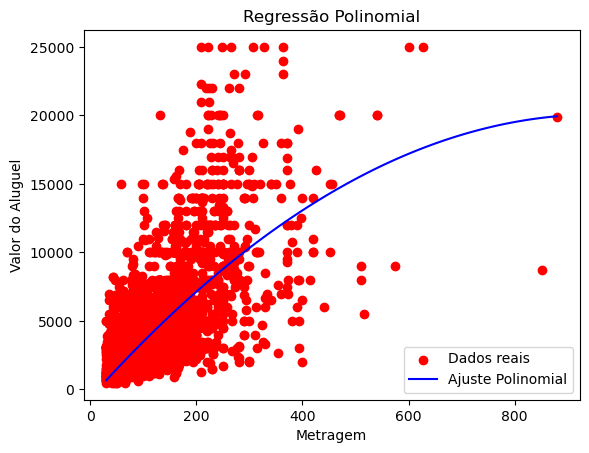

In [29]:
y_pred = model.predict(x_test)

# CriarEmos uma sequência de valores X para a visualização, buscando a suavização
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_range_poly = poly_features.transform(x_range)
y_range_pred = model.predict(x_range_poly)

plt.scatter(X, y, color='red', label='Dados reais')  # Dados reais
plt.plot(x_range, y_range_pred, color='blue', label='Ajuste Polinomial')  # Linha do ajuste
plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Polinomial')
plt.legend()
plt.show()

In [ ]:
# O gráfico nos apresenta a curva que melhor se ajusta ao modelo

In [ ]:
# 5 - Refaça os passos anteriores, rodando um novo modelo, porém testando agora na fase de processamento o degree = 4. 
# Avalie se o resultado desse novo modelo está superior ao anterior.

In [30]:
poly_features = PolynomialFeatures(degree=4)

In [31]:
x_poly = poly_features.fit_transform(X)

In [32]:
x_poly

array([[1.00000000e+00, 4.80000000e+01, 2.30400000e+03, 1.10592000e+05,
        5.30841600e+06],
       [1.00000000e+00, 5.00000000e+01, 2.50000000e+03, 1.25000000e+05,
        6.25000000e+06],
       [1.00000000e+00, 4.00000000e+01, 1.60000000e+03, 6.40000000e+04,
        2.56000000e+06],
       ...,
       [1.00000000e+00, 2.66000000e+02, 7.07560000e+04, 1.88210960e+07,
        5.00641154e+09],
       [1.00000000e+00, 6.00000000e+02, 3.60000000e+05, 2.16000000e+08,
        1.29600000e+11],
       [1.00000000e+00, 2.48000000e+02, 6.15040000e+04, 1.52529920e+07,
        3.78274202e+09]])

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=0)

In [34]:
# Aplicando regressão linear nos dados transformados
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [35]:
print("Tamanho de x_test:", x_test.shape)
print("Tamanho de y_test:", y_test.shape)

Tamanho de x_test: (1441, 5)
Tamanho de y_test: (1441,)


D:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


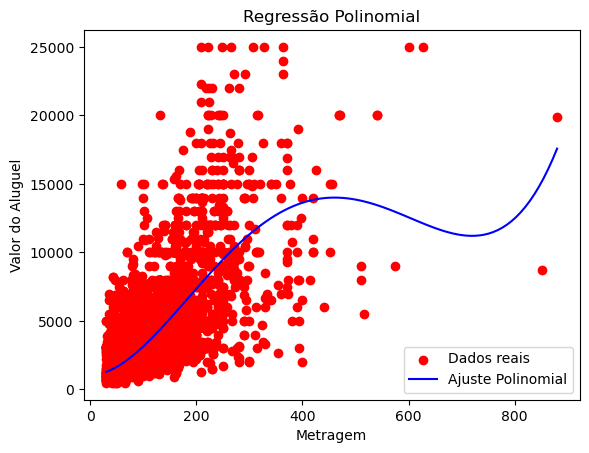

In [36]:
y_pred = model.predict(x_test)

# CriarEmos uma sequência de valores X para a visualização, buscando a suavização
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_range_poly = poly_features.transform(x_range)
y_range_pred = model.predict(x_range_poly)

plt.scatter(X, y, color='red', label='Dados reais')  # Dados reais
plt.plot(x_range, y_range_pred, color='blue', label='Ajuste Polinomial')  # Linha do ajuste
plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regressão Polinomial')
plt.legend()
plt.show()

In [ ]:
# Agora a curva faz este movimento mais ajustado à forma como os dados se comportam, ganhando mais curvas e demonstrando que mais pontos sao capturados
# pela linha

In [ ]:
# 6 - Explique com suas palavras o conceito e a diferença entre Elastic Net, Ridge e Lasso.
# Minimo: 4 linhas.

In [ ]:
# Elastic Net:

# Conceito: Combina as penalidades L1 (Lasso) e L2 (Ridge) na função de custo. Controla a mistura das penalidades com um parâmetro (α ou l1_ratio).
# Diferença: Busca o melhor dos dois mundos: seleção de variáveis (como Lasso) e tratamento de multicolinearidade (como Ridge). 
# Quando α=1, é Lasso; quando α=0, é Ridge.

# Ridge:

#Conceito: Adiciona uma penalidade L2 (soma dos quadrados dos coeficientes) à função de custo. 
# Isso encolhe os coeficientes em direção a zero, mas geralmente não os zera completamente.
# Diferença: Focado em reduzir a magnitude de todos os coeficientes para evitar overfitting e melhorar a estabilidade, 
# especialmente em dados com alta correlação entre as variáveis. Não realiza seleção de variáveis de forma eficaz.

# Lasso:

# Conceito: Adiciona uma penalidade L1 (soma dos valores absolutos dos coeficientes) à função de custo. 
# Isso também encolhe os coeficientes, mas tem a propriedade de forçar alguns coeficientes a serem exatamente zero, realizando seleção de variáveis.
# Diferença: Focado em criar modelos mais esparsos, eliminando variáveis menos importantes. 
# Pode ter dificuldades em selecionar uma variável de um grupo de altamente correlacionadas.